In [1]:
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
import torch
import numpy as np
from PIL import Image
import requests


In [4]:
# Load an image from file
image = Image.open('../test1.jpg')

w, h = image.size
holder = Image.new(mode="RGB", size=(w*2, h))

In [3]:
CHECKPOINT = "Intel/zoedepth-nyu"
image_processor = AutoImageProcessor.from_pretrained(CHECKPOINT)
model = AutoModelForDepthEstimation.from_pretrained(CHECKPOINT)

inputs = image_processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)
    predicted_depth = outputs.predicted_depth

prediction = torch.nn.functional.interpolate(
    predicted_depth.unsqueeze(1),
    size=image.size[::-1],
    mode="bicubic",
    align_corners=False,
)


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
[W228 17:00:55.329887296 NNPACK.cpp:62] Could not initialize NNPACK! Reason: Unsupported hardware.


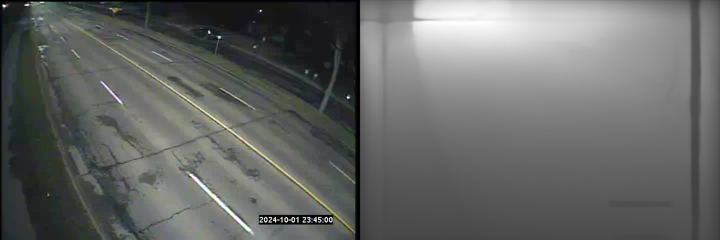

In [5]:
output = prediction.squeeze().cpu().numpy()
formatted = (output * 255 / np.max(output)).astype("uint8")
depth = Image.fromarray(formatted)

holder.paste(depth, (w, 0))
holder.paste(image, (0, 0))
holder.resize((w, h//2))

In [6]:
import open3d as o3d
import plotly.graph_objects as go
import numpy as np

color_image = np.asarray(image)
depth_image = (output * 255 / np.max(output)).astype("uint8")

# Create Open3D images
color = o3d.geometry.Image(color_image)
depth = o3d.geometry.Image(depth_image)
color_np = np.asarray(color)
depth_np = np.asarray(depth)

rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(
    color, depth
)

# Create points cloud
pcd = o3d.geometry.PointCloud.create_from_rgbd_image(
    rgbd_image,
    o3d.camera.PinholeCameraIntrinsic(
        o3d.camera.PinholeCameraIntrinsicParameters.PrimeSenseDefault
    )
)

OSError: libGL.so.1: cannot open shared object file: No such file or directory

In [ ]:
prediction

In [ ]:
# squezee two first dimension the tensor 
prediction = prediction.squeeze(0).squeeze(0)   


In [ ]:
prediction = prediction.cpu().numpy()
 # Normalize the depth values
min_depth = np.min(prediction)
max_depth = np.max(prediction)
prediction = (prediction - min_depth) / (max_depth - min_depth)

In [ ]:
import numpy as np


import matplotlib.cm as cm


# Apply a colormap to the depth data
colormap = cm.viridis  # You can choose other colormaps like 'plasma', 'inferno', 'magma', 'jet', etc.
depth_colored = colormap(prediction)

# Convert the float values to uint8
depth_colored = (depth_colored[:, :, :3] * 255).astype('uint8')

# Create a new RGB image
depth = Image.fromarray(depth_colored)

In [ ]:
depth